In [1]:
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from helper import train_loop
from helper import fashionClassifierMLP
from helper import get_data
from helper import labels_map

device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)
print(f"Using {device} device")


Using mps device


torch.Size([28, 28])
9


/Users/ignacio/nn/.venv/lib/python3.12/site-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


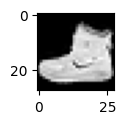

torch.Size([28, 28])
0


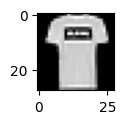

In [2]:
# print first sample of the training data
training_data, test_data = get_data()
print(training_data.data[0].shape)
print(training_data.train_labels[0].item())
# show image
# height of 100px and width of 100px
plt.figure(figsize=(1, 1))
plt.imshow(training_data.data[0], cmap="gray")
plt.show()

# print second image
print(training_data.data[1].shape)
print(training_data.train_labels[1].item())
# show image
plt.figure(figsize=(1, 1))
plt.imshow(training_data.data[1], cmap="gray")
plt.show()

In [3]:
# split train dataset into train+validation
training_data, validation_data = torch.utils.data.random_split(training_data, [50000, 10000])


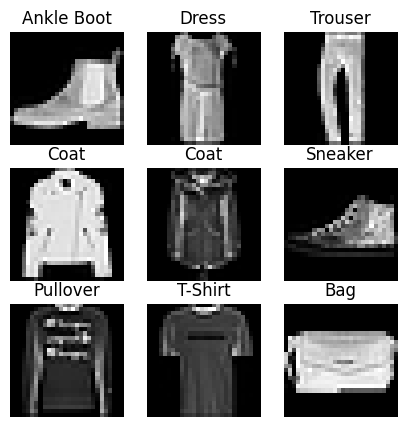

In [4]:

figure = plt.figure(figsize=(5, 5))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [5]:
batch_size = 128

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

for X, y in test_dataloader:
    # N is the batch size
    # C is the classification label
    # H and W are height and width
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([128, 1, 28, 28])
Shape of y: torch.Size([128]) torch.int64


In [6]:

model = fashionClassifierMLP()
print(model)

fashionClassifierMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [8]:

model.train()
epochs = 200
lossFn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.0001, weight_decay=1e-4)


train_loop(epochs, train_dataloader, model, lossFn, optimizer)

# evaluate the model on the evaluation dataset
model.eval()
size = len(validation_data)
num_batches = len(test_dataloader)
test_loss, correct = 0, 0
with torch.inference_mode():
    for image, expected_label in test_dataloader:
        pred = model(image)
        test_loss += lossFn(pred, expected_label).item()
        correct += (pred.argmax(1) == expected_label).type(torch.float).sum().item()



epoch 0 loss 1.7523648738861084
epoch 1 loss 1.7692807912826538
epoch 2 loss 1.7241252660751343
epoch 3 loss 1.7800028324127197
epoch 4 loss 1.7694146633148193
epoch 5 loss 1.7028290033340454
epoch 6 loss 1.6251773834228516
epoch 7 loss 1.6494991779327393
epoch 8 loss 1.729413390159607
epoch 9 loss 1.719395399093628
epoch 10 loss 1.6173105239868164
epoch 11 loss 1.5308300256729126
epoch 12 loss 1.6494064331054688
epoch 13 loss 1.4889583587646484
epoch 14 loss 1.6000721454620361


KeyboardInterrupt: 